<a href="https://colab.research.google.com/github/JWDP/Analisis-Sentimen-dengan-IndoBERT/blob/main/AnalisisSentimen%20/IndoBERT/Analisis_Sentimen_EMLA_UNSIKA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import string
import numpy as np
import nltk
import unicodedata

from nltk.tokenize import word_tokenize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)


In [ ]:
# Mengambil data dari file
df = pd.read_csv('/content/emla_unsika.csv')

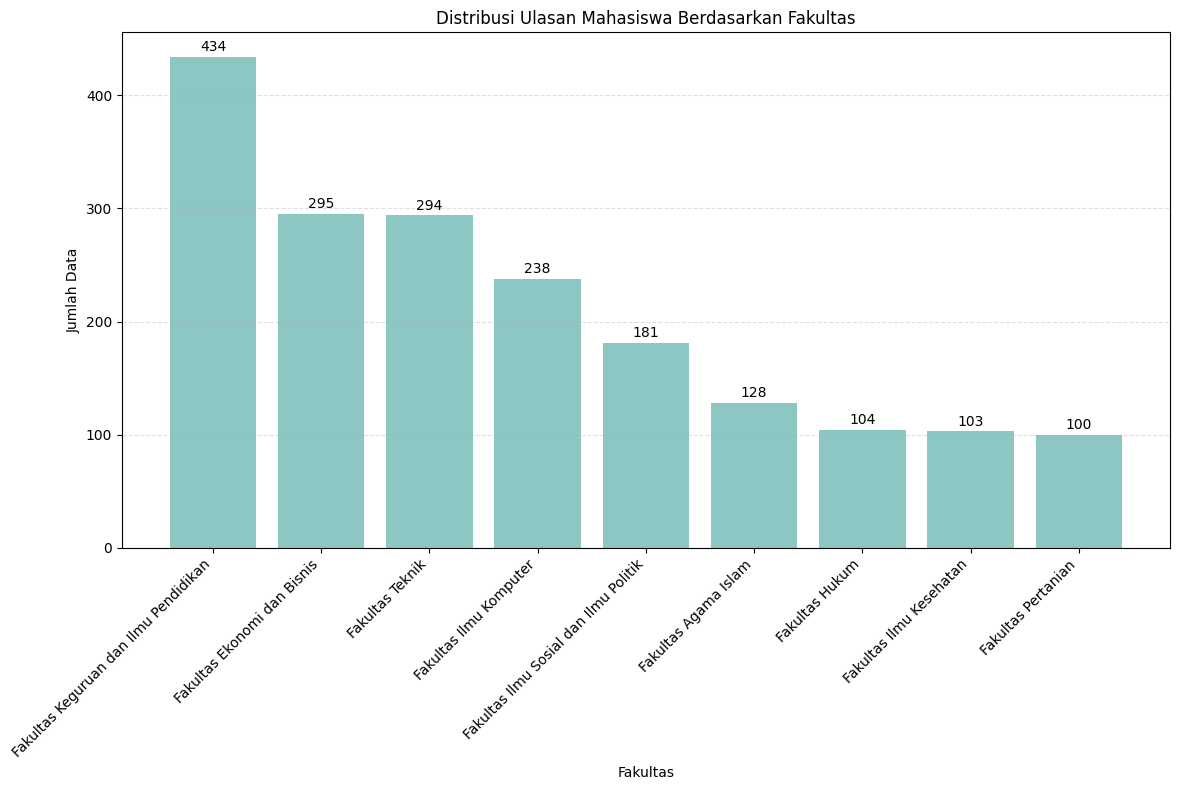

In [ ]:
# Mengecek Distribusi Data per Fakultas
import matplotlib.pyplot as plt

distribusi_fakultas = df["fakultas"].value_counts()

plt.figure(figsize=(12,8))

bars = plt.bar(
    distribusi_fakultas.index,
    distribusi_fakultas.values,
    color="#8CC7C4"
)

plt.title("Distribusi Ulasan Mahasiswa Berdasarkan Fakultas")
plt.xlabel("Fakultas")
plt.ylabel("Jumlah Data")

# Perbaikan posisi label (tepat di bawah bar)
plt.xticks(
    rotation=45,        # lebih rapi dari 45
    ha='right'         # center tepat di bawah bar
)

# Menampilkan jumlah di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        int(height),
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()  # penting agar tidak kepotong
plt.show()

# **PREPOCESSING**

## **Data Quality Assesment**

In [ ]:
# Show Upper Data
df.head()

,fakultas,angkatan,ulasan
0,Fakultas Keguruan dan Ilmu Pendidikan,2023,0
1,Fakultas Agama Islam,2023,-
2,Fakultas Agama Islam,2021,-
3,Fakultas Agama Islam,2021,-
4,Fakultas Pertanian,2024,-


In [ ]:
# Show Upper Data
df.tail()

,fakultas,angkatan,ulasan
1872,Fakultas Ilmu Sosial dan Ilmu Politik,2024,wow
1873,Fakultas Ilmu Komputer,2023,wow incredible
1874,Fakultas Agama Islam,2022,y
1875,Fakultas Ilmu Komputer,2023,yang kurang baik di perbaiki
1876,Fakultas Keguruan dan Ilmu Pendidikan,2023,🙏🏻


In [ ]:
# Show info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1877 entries, 0 to 1876
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   fakultas  1877 non-null   object
 1   angkatan  1877 non-null   int64 
 2   ulasan    1877 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.1+ KB


In [ ]:
# UBAH TIPE DATA FAKULTAS DAN ULASAN
df["fakultas"] = df["fakultas"].astype(str)
df["ulasan"] = df["ulasan"].astype(str)
print(df.dtypes)

fakultas    object
angkatan     int64
ulasan      object
dtype: object


In [ ]:
# Check Number of Row and Columns
df.shape  #Jumlahnya bisa segini karna Baris yg nullnya langsung dihilangin

(1877, 3)

In [ ]:
#mengecek missing value
df.isnull().sum()

,0
fakultas,0
angkatan,0
ulasan,0


** → Cleaning → Normalisasi → labeling → Split Data → Tokenisasi indobert  **

## **Cleaning**

In [ ]:
# Menghitung Jumlah Data Duplikat
jumlah_duplikat = df.duplicated().sum()
print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 450


In [ ]:
duplikat = df[df.duplicated()]
print(duplikat)

                                   fakultas  angkatan  \
3                      Fakultas Agama Islam      2021   
5                        Fakultas Pertanian      2024   
7                        Fakultas Pertanian      2024   
9                        Fakultas Pertanian      2023   
10                       Fakultas Pertanian      2024   
...                                     ...       ...   
1723  Fakultas Keguruan dan Ilmu Pendidikan      2022   
1725  Fakultas Keguruan dan Ilmu Pendidikan      2023   
1763                        Fakultas Teknik      2024   
1768                         Fakultas Hukum      2024   
1830                        Fakultas Teknik      2022   

                                                 ulasan  
3                                                     -  
5                                                     -  
7                                                     -  
9                                                     -  
10                       

### **Penanganan Duplikat**

In [ ]:
df_duplikat = df.drop_duplicates(subset='ulasan', keep='first')

In [ ]:
df_duplikat.duplicated().sum()

np.int64(0)

In [ ]:
# pola emoji yang cukup komprehensif
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA70-\U0001FAFF"  # additional symbols
    "\U00002600-\U000026FF"  # misc symbols
    "]+", flags=re.UNICODE
)

def remove_emoji_regex(text):
    if not isinstance(text, str):
        text = str(text)
    text = unicodedata.normalize('NFKC', text)
    text = emoji_pattern.sub('', text)
    text = re.sub(r'[\uFE0F\u200D]', '', text)
    return text

def cleansing(text):
    text = remove_emoji_regex(text)
    text = re.sub(r'[\n\r]+', ' ', text)             # hilangkan enter
    text = re.sub(r'\d+', '', text)                  # hapus angka
    text = re.sub(r'[()]', '', text)           # hapus ()
    text = re.sub(r'["“”‘’\'`]', '', text)            # hapus semua jenis tanda kutip
    text = re.sub(r'[-–—/_]', ' ', text)             # ganti - / – — _ jadi spasi
    text = re.sub(r'[^\w\s]', ' ', text)             # hapus simbol non huruf/angka kecuali spasi
    text = re.sub(r'[\-\–\—\‒\―]+', ' ', text)       # hapus semua tanda penghubung
    text = re.sub(r'\s+', ' ', text).strip()         # rapikan spasi
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # sisakan hanya huruf
    return text

# Terapkan
df_duplikat['ulasan'] = df_duplikat['ulasan'].astype(str).apply(cleansing)

/tmp/ipykernel_2273/3869548018.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_duplikat['ulasan'] = df_duplikat['ulasan'].astype(str).apply(cleansing)


In [ ]:
df_duplikat.shape

(1201, 3)

In [ ]:
# Hapus baris kosong atau tanda tunggal
df_duplikat = df_duplikat[~df_duplikat['ulasan'].isin(['0', '-', '.','_','...', '--','..', '—', '?:-)'])]

In [ ]:
df_duplikat = df_duplikat[~df_duplikat['ulasan'].astype(str).str.match(r'^[\W_]+$', na=False)]

In [ ]:
#mengecek missing value
df_duplikat.isnull().sum()

,0
fakultas,0
angkatan,0
ulasan,0


In [ ]:
df_duplikat.shape

(1201, 3)

In [ ]:
df_duplikat.to_csv('hasil_penghapusanduplikat.csv', index=False)

### **Tanpa Penghapusan  Duplikat**

Tidak Menghpus Duplikat karna setiap orang yang ngisi berbeda orang bukan orang yang sama jadi data duplikat tersebut masih dapat digunakan

In [ ]:
# Load data from local file
#df = pd.read_csv('/content/penelitian_ulasan.csv')

In [ ]:
# Menghapus emoji
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  #symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA70-\U0001FAFF"  # additional symbols
    "\U00002600-\U000026FF"  # misc symbols
    "]+",
    flags=re.UNICODE
)

def remove_emoji_regex(text):
    if not isinstance(text, str):
        text = str(text)
    text = unicodedata.normalize('NFKC', text)
    text = emoji_pattern.sub('', text)
    text = re.sub(r'[\uFE0F\u200D]', '', text)
    return text

def cleansing(text):
    text = remove_emoji_regex(text)
    text = re.sub(r'[\n\r]+', ' ', text)         # Menghilangkan enter
    text = re.sub(r'[()"“”‘’\'`]', '', text)     # Menghapus tanda kutip & kurung
    text = re.sub(r'[-–—/_]', ' ', text)         # Mengganti tanda penghubung jadi spasi
    text = re.sub(r'[^\w\s]', ' ', text)         # Menghapus simbol selain huruf/angka/spasi
    text = re.sub(r'\s+', ' ', text).strip()     # Merapikan spasi
    text = text.lower()                          # Mengubah jadi huruf kecil
    return text

# Terapkan fungsi cleansing ke kolom 'ulasan'
df['ulasan_clean'] = df['ulasan'].astype(str).apply(cleansing)

# Ganti teks kosong atau titik menjadi NaN
df['ulasan_clean'].replace(['', ' ', '.', '-', '_', '?', 'nan'], np.nan, inplace=True)

/tmp/ipykernel_601/2639275927.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ulasan_clean'].replace(['', ' ', '.', '-', '_', '?', 'nan'], np.nan, inplace=True)


In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

fakultas          0
angkatan          0
ulasan            0
ulasan_clean    371
dtype: int64


In [ ]:
# Membandingkan data sebelum dan sesudah cleaning
df['ulasan_clean'] = df['ulasan'].apply(cleansing)
df[['ulasan', 'ulasan_clean']].tail(10)

,ulasan,ulasan_clean
1867,Untuk sistem pelayanan lebih di tingkatkan lag...,untuk sistem pelayanan lebih di tingkatkan lag...
1868,Untuk terus meningkatkan kualitas layanan akad...,untuk terus meningkatkan kualitas layanan akad...
1869,vasilitasnya tolong di perbaiki,vasilitasnya tolong di perbaiki
1870,Waktu respons admin akademik terhadap perminta...,waktu respons admin akademik terhadap perminta...
1871,Web nya buatin yang lebih bagus dan responsif,web nya buatin yang lebih bagus dan responsif
1872,wow,wow
1873,wow incredible,wow incredible
1874,y,y
1875,yang kurang baik di perbaiki,yang kurang baik di perbaiki
1876,🙏🏻,


In [ ]:
# FINAL Cleansing (hapus baris kosong, tanda baca, simbol)

# Hapus baris yang kosong setelah dibersihkan
df = df[df["ulasan_clean"] != ""]

# Menghapus spasi berlebih
df["ulasan_clean"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# hapus yang benar-benar kosong
df = df[df['ulasan_clean'].str.strip() != '']

In [ ]:
# Membandingkan data sebelum dan sesudah cleaning
df['ulasan_clean'] = df['ulasan'].apply(cleansing)
df[['ulasan', 'ulasan_clean']].head(10)

,ulasan,ulasan_clean
0,0,0
303,"""Bapak/Ibu sekalian, terima kasih banyak atas ...",bapak ibu sekalian terima kasih banyak atas se...
372,1. Dimohon untuk fasilitas yang sering rusak a...,1 dimohon untuk fasilitas yang sering rusak ag...
373,1. infocus banyak yang tidak nyala\n2. Ac yang...,1 infocus banyak yang tidak nyala 2 ac yang ti...
374,1. KRS setiap mata kuliah harusnya tertera di ...,1 krs setiap mata kuliah harusnya tertera di s...
375,"1. Menurutku, lebih banyak praktikum langsung\...",1 menurutku lebih banyak praktikum langsung bi...
376,"1. Mohon disediakan mushola di FKIP, sebab kal...",1 mohon disediakan mushola di fkip sebab kalau...
377,1. Optimalisasi Desain Kuesioner\n- Gunakan pe...,1 optimalisasi desain kuesioner gunakan pertan...
378,1. Perbaiki dan lengkapi fasilitas seperti per...,1 perbaiki dan lengkapi fasilitas seperti perp...
379,1.Penguatan Metode Pengajaran Dosen\n-Gunakan ...,1 penguatan metode pengajaran dosen gunakan pe...


In [ ]:
df.shape

(1506, 4)

In [ ]:
df.to_csv('ulasan_cleaning.csv', index=False)

## **Normalisasi**

Berfungsi untuk menyamaratakan arti kata walaupun indobert dapat memahamibahasa-bahasa gaul akan tetapi normalisasi ini dapat digunakan untuk memperjelas setiap kalimat yg typo


In [ ]:
# Load data from local file
df = pd.read_csv('/content/ulasan_cleaning.csv')

In [ ]:
# Normalisasi kata sesuai kolom 'ulasan' dengan metode manual karna hanya memperbaiki kata typo saja
normalisasi_kata = {
    "(": " ",
    ")": " ",
    "&": " ",
    "-": " ",
    ",": " ",
    "/": " atau ",
    "nyaa": " ",
    "nya": " ",
    "y": " ",
    "saram": "saran",
    "dipagi": "di pagi",
    "ppt": "presentasi",
    "kaprodi": "ketua program studi",
    "wadek": "wakil dekan",
    "didalam": "di dalam",
    "tapi": "tetapi",
    "tp": "tetapi",
    "diupdate": "diperbarui",
    "biar": "agar",
    "sebab": "karena",
    "karna": "karena",
    "krn": "karena",
    "mesjid": "masjid",
    "0": " ",
    "1": "satu",
    "2": "dua",
    "3": "tiga",
    "4": "empat",
    "5": "lima",
    "6": "enam",
    "7": "tujuh",
    "8": "delapan",
    "dikelas": "di kelas",
    "di tingkatkan": "ditingkatkan",
    "ditingkat": "ditingkatkan",
    "tingkatin": "ditingkatkan",
    "bangettt": "banget",
    "bgt": "banget",
    "di perbaiki": "diperbaiki",
    "stop kontak": "stopkontak",
    "terminal": "stopkontak",
    "di nyalain": "dinyalakan",
    "duaaa": "dua",
    "kalo": "kalau",
    "kl": "kalau",
    "klo": "kalau",
    "dibenerin": "dibenarkan",
    "terimakasih": "terima kasih",
    "udah": "sudah",
    "aja": "saja",
    "di sosialisasikan": "disosialisasikan",
    "b": "biasa",
    "tolongggggg": "tolong",
    "tolongg": "tolong",
    "secape": "selelah",
    "bagusin": "baguskan",
    "selqlu": "selalu",
    "baikkk": "baik",
    "dikelas": "di kelas",
    "lab": "laboratorium",
    "kab": "laboratorium",
    "yg": "yang",
    "yag": "yang",
    "powerpoint": "proyektor",
    "infokus": "proyektor",
    "melaksnakan": "melaksanakan",
    "prodi": "program studi",
    "bbbb": "bagus",
    "di rasakan": "dirasakan",
    "kearah": "ke arah",
    "memilikikemampuan": "memiliki kemampuan",
    "di lihat": "dilihat",
    "di perhatikan": "diperhatikan",
    "d": "di",
    "mengimprove": "memperbaiki",
    "di improve": "diperbaiki",
    "di perbanyak": "diperbanyak",
    "di gantikan": "digantikan",
    "asdos": "asisten dosen",
    "permasalhan": "permasalahan",
    "tu": "tata usaha",
    "di pakai": "dipakai",
    "dasilitas": "fasilitas",
    "di tambah": "ditambah",
    "pra sarana": "prasarana",
    "di pertahanan": "dipertahankan",
    "di sediakan": "disediakan",
    "rapih": "rapi",
    "wi-fi": "wifi",
    "wi fi": "wifi",
    "menganggu": "mengganggu",
    "merubah": "mengubah",
    "kedepannya": "ke depannya",
    "di evaluasikan": "dievaluasikan",
    "kembai": "kembali",
    "di peluaskan": "diperluas",
    "kuliahpengajarandan": "kuliah pengajaran dan",
    "akademisdan": "akademis dan",
    "untulk": "untuk",
    "kedalam": "ke dalam",
    "kasian": "kasihan",
    "di service": "diservis",
    "lagii": "lagi",
    "perku": "perlu",
    "pkabel": "kabel",
    "dibagusin": "dibaguskan",
    "basarnya": "besarnya",
    "mk": "mata kuliah",
    "dinginc": "dingin",
    "ummum": "umum",
    "univ": "universitas",
    "hi": "hubungan internasional",
    "sesaui": "sesuai",
    "semual": "semua",
    "gk": "tidak",
    "ga": "tidak",
    "gpp": "tidak apa apa",
    "utk": "untuk",
    "sm": "sama",
    "jd": "jadi",
    "dgn": "dengan",
    "dr": "dari",
    "jg": "juga",
    "jjur": "jujur",
    "perhatiakan": "perhatikan",
    "pemelajaran": "pembelajaran",
    "memili": "memiliki",
    "paa": "pada",
    "wow": "bagus"
}

def normalize_text(text):
    words = text.split()
    normalized_words = [normalisasi_kata[word] if word in normalisasi_kata else word for word in words]
    return " ".join(normalized_words)

In [ ]:
df['ulasan_bersih'] = df['ulasan_clean'].apply(normalize_text)
df[['ulasan_clean', 'ulasan_bersih']].head(10)

,ulasan_clean,ulasan_bersih
0,0,
303,bapak ibu sekalian terima kasih banyak atas se...,bapak ibu sekalian terima kasih banyak atas se...
372,1 dimohon untuk fasilitas yang sering rusak ag...,satu dimohon untuk fasilitas yang sering rusak...
373,1 infocus banyak yang tidak nyala 2 ac yang ti...,satu infocus banyak yang tidak nyala dua ac ya...
374,1 krs setiap mata kuliah harusnya tertera di s...,satu krs setiap mata kuliah harusnya tertera d...
375,1 menurutku lebih banyak praktikum langsung bi...,satu menurutku lebih banyak praktikum langsung...
376,1 mohon disediakan mushola di fkip sebab kalau...,satu mohon disediakan mushola di fkip karena k...
377,1 optimalisasi desain kuesioner gunakan pertan...,satu optimalisasi desain kuesioner gunakan per...
378,1 perbaiki dan lengkapi fasilitas seperti perp...,satu perbaiki dan lengkapi fasilitas seperti p...
379,1 penguatan metode pengajaran dosen gunakan pe...,satu penguatan metode pengajaran dosen gunakan...


In [ ]:
df.head()

,fakultas,angkatan,ulasan,ulasan_clean,ulasan_bersih
0,Fakultas Keguruan dan Ilmu Pendidikan,2023,0,0,
303,Fakultas Ekonomi dan Bisnis,2024,"""Bapak/Ibu sekalian, terima kasih banyak atas ...",bapak ibu sekalian terima kasih banyak atas se...,bapak ibu sekalian terima kasih banyak atas se...
372,Fakultas Keguruan dan Ilmu Pendidikan,2024,1. Dimohon untuk fasilitas yang sering rusak a...,1 dimohon untuk fasilitas yang sering rusak ag...,satu dimohon untuk fasilitas yang sering rusak...
373,Fakultas Keguruan dan Ilmu Pendidikan,2024,1. infocus banyak yang tidak nyala\n2. Ac yang...,1 infocus banyak yang tidak nyala 2 ac yang ti...,satu infocus banyak yang tidak nyala dua ac ya...
374,Fakultas Hukum,2023,1. KRS setiap mata kuliah harusnya tertera di ...,1 krs setiap mata kuliah harusnya tertera di s...,satu krs setiap mata kuliah harusnya tertera d...


In [ ]:
# FINAL Cleansing (hapus baris kosong, tanda baca, simbol)

# Hapus baris yang kosong setelah dibersihkan
df = df[df["ulasan_bersih"] != ""]

# Menghapus spasi berlebih
df["ulasan_bersih"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# hapus yang benar-benar kosong
df = df[df['ulasan_bersih'].str.strip() != '']

print("\nSetelah Cleansing:")
print(df[["ulasan_bersih"]].head())


Setelah Cleansing:
                                         ulasan_bersih
303  bapak ibu sekalian terima kasih banyak atas se...
372  satu dimohon untuk fasilitas yang sering rusak...
373  satu infocus banyak yang tidak nyala dua ac ya...
374  satu krs setiap mata kuliah harusnya tertera d...
375  satu menurutku lebih banyak praktikum langsung...


In [ ]:
#mengecek missing value
df.isnull().sum()

,0
fakultas,0
angkatan,0
ulasan,0
ulasan_clean,0
ulasan_bersih,0


In [ ]:
df.shape

(1504, 5)

In [ ]:
df.head()

,fakultas,angkatan,ulasan,ulasan_clean,ulasan_bersih
303,Fakultas Ekonomi dan Bisnis,2024,"""Bapak/Ibu sekalian, terima kasih banyak atas ...",bapak ibu sekalian terima kasih banyak atas se...,bapak ibu sekalian terima kasih banyak atas se...
372,Fakultas Keguruan dan Ilmu Pendidikan,2024,1. Dimohon untuk fasilitas yang sering rusak a...,1 dimohon untuk fasilitas yang sering rusak ag...,satu dimohon untuk fasilitas yang sering rusak...
373,Fakultas Keguruan dan Ilmu Pendidikan,2024,1. infocus banyak yang tidak nyala\n2. Ac yang...,1 infocus banyak yang tidak nyala 2 ac yang ti...,satu infocus banyak yang tidak nyala dua ac ya...
374,Fakultas Hukum,2023,1. KRS setiap mata kuliah harusnya tertera di ...,1 krs setiap mata kuliah harusnya tertera di s...,satu krs setiap mata kuliah harusnya tertera d...
375,Fakultas Pertanian,2023,"1. Menurutku, lebih banyak praktikum langsung\...",1 menurutku lebih banyak praktikum langsung bi...,satu menurutku lebih banyak praktikum langsung...


In [ ]:
df.to_csv('hasil_normalisasii.csv', index=False)

## **Labeling**

labeling ini menggunakan indonesian roberta yang biasa digunakan untuk mengklasifikasikan analisis sentimen

Labeling data menggunakan RoBERTa (Robustly Optimized BERT Pretraining Approach) adalah metode automated labeling atau auto-labeling yang memanfaatkan model bahasa prapelatihan (pre-trained language model) untuk memberikan label pada teks mentah secara cepat dan akurat. RoBERTa, sebagai turunan BERT yang dioptimalkan, sangat efektif untuk tugas klasifikasi teks, analisis sentimen, dan pelabelan topik.

Kenapa Harus tetap ada Labeling padahal fungsi IndoBERTkan juga bisa untuk melabelkan karena  Label dipakai untuk mengecek tebakan itu benar atau salah sedangkan model menghitung loss nya

In [ ]:
# Load data from local file
df = pd.read_csv('/content/hasil_normalisasii.csv')

In [ ]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

def auto_label(text):
    result = sentiment_model(text[:512])[0]['label']
    return 1 if result == 'positive' else 0

df['label'] = df['ulasan_bersih'].apply(auto_label)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
from transformers import pipeline # memanggil pipeline siap pakai dari HuggingFace (Menggunakan model yang sudah jadi)

sentiment_model = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"  #Labeling menggunakan model RoBERTa Bahasa Indonesia dengan Dataset latihnya bukan data UNSIKA
)

def auto_label(text):
    result = sentiment_model(text[:512])[0]['label']
    return 1 if result == 'positive' else 0

df['label'] = df['ulasan_bersih'].apply(auto_label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
df[['ulasan_bersih', 'label']].head(10)

,ulasan_bersih,label
0,bapak ibu sekalian terima kasih banyak atas se...,1
1,satu dimohon untuk fasilitas yang sering rusak...,0
2,satu infocus banyak yang tidak nyala dua ac ya...,0
3,satu krs setiap mata kuliah harusnya tertera d...,0
4,satu menurutku lebih banyak praktikum langsung...,1
5,satu mohon disediakan mushola di fkip karena k...,0
6,satu optimalisasi desain kuesioner gunakan per...,0
7,satu perbaiki dan lengkapi fasilitas seperti p...,0
8,satu penguatan metode pengajaran dosen gunakan...,0
9,ac di fh satu suka panas pak bu,1


In [ ]:
df['label'].value_counts()

,count
label,
1,770
0,734


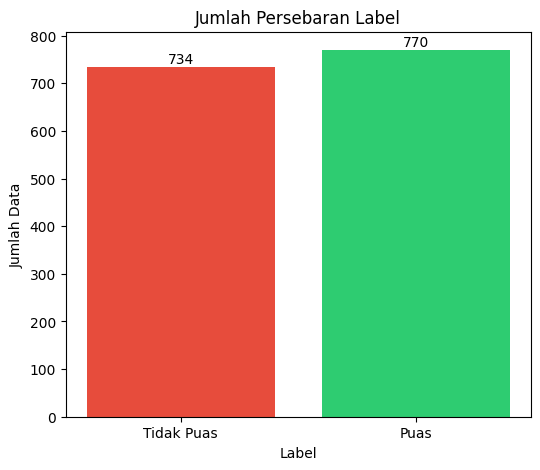

In [ ]:
# Menampilkan Bar Chart jumlah persebaran label
import matplotlib.pyplot as plt

# Mapping label
label_map = {0: "Tidak Puas", 1: "Puas"}

# Hitung jumlah
counts = df['label'].map(label_map).value_counts()

# Pastikan urutan
counts = counts[["Tidak Puas", "Puas"]]

# Warna
colors = ['#e74c3c', '#2ecc71']

# Plot
plt.figure(figsize=(6,5))
bars = plt.bar(counts.index, counts.values, color=colors)

plt.title("Jumlah Persebaran Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

# Tambahkan jumlah di ATAS bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,   # posisi di atas
        int(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

In [ ]:
#df.to_csv("ulasan_berlabel(RoBERTA).csv", index=False)

## **Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Load data from local file
#df = pd.read_csv('/content/ulasan_berlabel(FIKSs).csv')

In [ ]:
from sklearn.model_selection import train_test_split

# Mengambil SEMUA kolom yang dibutuhkan
X = df[['ulasan_bersih', 'fakultas']]
y = df['label']

# 80% train, 20% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


In [ ]:
df_train = pd.DataFrame({
    'ulasan_bersih': X_train['ulasan_bersih'],
    'fakultas': X_train['fakultas'],
    'label': y_train
})

df_val = pd.DataFrame({
    'ulasan_bersih': X_val['ulasan_bersih'],
    'fakultas': X_val['fakultas'],
    'label': y_val
})

df_test = pd.DataFrame({
    'ulasan_bersih': X_test['ulasan_bersih'],
    'fakultas': X_test['fakultas'],
    'label': y_test
})

In [ ]:
df_train.to_csv("train_data.csv", index=False)
df_val.to_csv("val_data.csv", index=False)
df_test.to_csv("test_data.csv", index=False)

In [ ]:
# Hitung jumlah data
train_count = len(df_train)
val_count   = len(df_val)
test_count  = len(df_test)

total = train_count + val_count + test_count

# DataFrame statistik
split_stats = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Testing'],
    'Jumlah Data': [train_count, val_count, test_count],
    'Persentase': [
        f"{train_count/total:.0%}",
        f"{val_count/total:.0%}",
        f"{test_count/total:.0%}"
    ]
})

# Tambah total
split_stats.loc[len(split_stats)] = ['Total', total, '100%']

split_stats

,Dataset,Jumlah Data,Persentase
0,Training,1203,80%
1,Validation,150,10%
2,Testing,151,10%
3,Total,1504,100%


In [ ]:
print("Train:")
print(df_train['label'].value_counts())

print("\nValidation:")
print(df_val['label'].value_counts())

print("\nTest:")
print(df_test['label'].value_counts())

Train:
label
1    616
0    587
Name: count, dtype: int64

Validation:
label
1    77
0    73
Name: count, dtype: int64

Test:
label
1    77
0    74
Name: count, dtype: int64


# **MODELING**

## **Tokenisasi**

Pada penelitian ini tokenisasi yang digunakan yaitu tokenisasi yang telah disediakan dari IndoBERTnya

In [ ]:
# Load data from local file
#df = pd.read_csv('/content/emla_unsika.csv')

In [ ]:
from transformers import AutoTokenizer
import torch

In [ ]:
#load Tokenazier IndoBERT
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

#mengambil Teks & Label dari Data Split
train_texts = df_train['ulasan_bersih'].tolist()
val_texts   = df_val['ulasan_bersih'].tolist()
test_texts  = df_test['ulasan_bersih'].tolist()

train_labels = df_train['label'].tolist()
val_labels   = df_val['label'].tolist()
test_labels  = df_test['label'].tolist()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
#mengubah label ke angka
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_labels = le.fit_transform(train_labels)
val_labels   = le.transform(val_labels)
test_labels  = le.transform(test_labels)

print(dict(zip(le.classes_, le.transform(le.classes_))))

#Proses Tokenisasi
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [ ]:
# Mengubah ke Format Dataset PyTorch
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

#Membuat data Final
train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset   = SentimentDataset(val_encodings, val_labels)
test_dataset  = SentimentDataset(test_encodings, test_labels)

In [ ]:
#save tokenisasi
torch.save(train_encodings, "train_encodings.pt")
torch.save(train_labels, "train_labels.pt")

torch.save(val_encodings, "val_encodings.pt")
torch.save(val_labels, "val_labels.pt")

torch.save(test_encodings, "test_encodings.pt")
torch.save(test_labels, "test_labels.pt")

In [ ]:
#Menyimpan tokenizer
tokenizer.save_pretrained("tokenizer_indobert")

('tokenizer_indobert/tokenizer_config.json',
 'tokenizer_indobert/tokenizer.json')

In [ ]:
#Mengambil salah satu data yang telah di tokenisasi
text = df["ulasan_bersih"].iloc[10]
print("Teks Asli:")
print(text)

Teks Asli:
ac di lantai dua kadang panas pak bu tidak berfungsi beberapa proyektor di lantai dua juga tidak bisa digunakan


In [ ]:
# Melihat hasil tokenisasi
tokens = tokenizer.tokenize(text)
print("\nHasil Tokenisasi:")
print(tokens)


Hasil Tokenisasi:
['ac', 'di', 'lantai', 'dua', 'kadang', 'panas', 'pak', 'bu', 'tidak', 'berfungsi', 'beberapa', 'proyektor', 'di', 'lantai', 'dua', 'juga', 'tidak', 'bisa', 'digunakan']


In [ ]:
# Melihat hasil Token dan ID
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("\nToken dan ID:")
for token, id in zip(tokens, token_ids):
    print(f"{token} -> {id}")


Token dan ID:
ac -> 627
di -> 26
lantai -> 3375
dua -> 662
kadang -> 3597
panas -> 1990
pak -> 556
bu -> 379
tidak -> 119
berfungsi -> 2942
beberapa -> 388
proyektor -> 20763
di -> 26
lantai -> 3375
dua -> 662
juga -> 186
tidak -> 119
bisa -> 166
digunakan -> 781


In [ ]:
encoded = tokenizer(
    text,
    padding='max_length',
    truncation=True,
    max_length=20
)

print("\nInput IDs:")
print(encoded["input_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])


Input IDs:
[2, 627, 26, 3375, 662, 3597, 1990, 556, 379, 119, 2942, 388, 20763, 26, 3375, 662, 186, 119, 166, 3]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## **Fine-Tunning**

In [ ]:
from transformers import AutoModelForSequenceClassification

#Load Model
model_name = "indobenchmark/indobert-base-p1"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # jumlah kelas sentimen
)


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Membuat Metrics evaluasi
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
#Skenario Eksperience
learning_rates = [2e-5, 3e-5]
epochs_list = [2, 3, 4]
batch_sizes = [16, 32]

scenarios = []
count = 1

for le in learning_rates:
    for ep in epochs_list:
        for batch in batch_sizes:
            grad_accum = batch // 8

            scenarios.append({
                "name": f"S{count}_LE{le}_EP{ep}_B{batch}",
                "le": le,
                "epochs": ep,
                "grad_accum": grad_accum,
                "target_batch": batch
            })

            count += 1

In [ ]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification
import os

experiment_results = []

for scen in scenarios:

    print(f"\n Training {scen['name']}")

    args = TrainingArguments(
        output_dir=f"./results/{scen['name']}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,

        learning_rate=scen["le"],
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=scen["grad_accum"],
        num_train_epochs=scen["epochs"],

        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",

        save_total_limit=1,
        fp16=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        processing_class=tokenizer
    )

    # train
    trainer.train()

    # mengambil train loss
    train_loss = None
    for log in reversed(trainer.state.log_history):
        if "loss" in log:
            train_loss = log["loss"]
            break

    # evaluasi
    eval_result = trainer.evaluate()

    # Menyimpan model terbaik
    best_model_path = f"./best_model/{scen['name']}"
    os.makedirs(best_model_path, exist_ok=True)

    trainer.save_model(best_model_path)
    tokenizer.save_pretrained(best_model_path)

    # Menyimpan Hasil
    experiment_results.append({
        "Skenario": scen["name"],
        "LE": scen["le"],
        "Epoch": scen["epochs"],
        "Batch": scen["target_batch"],

        "Train Loss": train_loss,
        "Eval Loss": eval_result["eval_loss"],

        "Accuracy": eval_result["eval_accuracy"],
        "Precision": eval_result["eval_precision"],
        "Recall": eval_result["eval_recall"],
        "F1": eval_result["eval_f1"],

        "Model_Path": best_model_path
    })



 Training S1_LE2e-05_EP2_B16


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.759839,0.203371,0.920000,0.924051,0.901235,0.948052
2,0.409187,0.214079,0.933333,0.935065,0.935065,0.935065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Meanmpilkan tabel hasil eksperimen
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df


,Skenario,LE,Epoch,Batch,Train Loss,Eval Loss,Accuracy,Precision,Recall,F1,Model_Path
2,S3_LE2e-05_EP3_B16,0.00002,3,16,0.097883,0.246546,0.966667,0.961538,0.974026,0.967742,./best_model/S3_LE2e-05_EP3_B16
4,S5_LE2e-05_EP4_B16,0.00002,4,16,0.023722,0.336191,0.960000,0.949367,0.974026,0.961538,./best_model/S5_LE2e-05_EP4_B16
5,S6_LE2e-05_EP4_B32,0.00002,4,32,0.031933,0.369295,0.960000,0.949367,0.974026,0.961538,./best_model/S6_LE2e-05_EP4_B32
3,S4_LE2e-05_EP3_B32,0.00002,3,32,0.030796,0.216455,0.953333,0.972973,0.935065,0.953642,./best_model/S4_LE2e-05_EP3_B32
10,S11_LE3e-05_EP4_B16,0.00003,4,16,0.004018,0.480546,0.953333,0.926829,0.987013,0.955975,./best_model/S11_LE3e-05_EP4_B16
11,S12_LE3e-05_EP4_B32,0.00003,4,32,0.062803,0.573653,0.953333,0.926829,0.987013,0.955975,./best_model/S12_LE3e-05_EP4_B32
6,S7_LE3e-05_EP2_B16,0.00003,2,16,0.074309,0.534151,0.946667,0.936709,0.961039,0.948718,./best_model/S7_LE3e-05_EP2_B16
1,S2_LE2e-05_EP2_B32,0.00002,2,32,0.398454,0.253194,0.940000,0.925000,0.961039,0.942675,./best_model/S2_LE2e-05_EP2_B32
9,S10_LE3e-05_EP3_B32,0.00003,3,32,0.271623,0.418742,0.940000,0.914634,0.974026,0.943396,./best_model/S10_LE3e-05_EP3_B32
0,S1_LE2e-05_EP2_B16,0.00002,2,16,0.409187,0.214079,0.933333,0.935065,0.935065,0.935065,./best_model/S1_LE2e-05_EP2_B16


In [ ]:
# Ubah ke DataFrame
df_exp = pd.DataFrame(experiment_results)

# Lihat isi
print(df_exp)

               Skenario       LE  Epoch  Batch  Train Loss  Eval Loss  \
0    S1_LE2e-05_EP2_B16  0.00002      2     16    0.409187   0.214079   
1    S2_LE2e-05_EP2_B32  0.00002      2     32    0.398454   0.253194   
2    S3_LE2e-05_EP3_B16  0.00002      3     16    0.097883   0.246546   
3    S4_LE2e-05_EP3_B32  0.00002      3     32    0.030796   0.216455   
4    S5_LE2e-05_EP4_B16  0.00002      4     16    0.023722   0.336191   
5    S6_LE2e-05_EP4_B32  0.00002      4     32    0.031933   0.369295   
6    S7_LE3e-05_EP2_B16  0.00003      2     16    0.074309   0.534151   
7    S8_LE3e-05_EP2_B32  0.00003      2     32    0.098753   0.546722   
8    S9_LE3e-05_EP3_B16  0.00003      3     16    0.026899   0.734983   
9   S10_LE3e-05_EP3_B32  0.00003      3     32    0.271623   0.418742   
10  S11_LE3e-05_EP4_B16  0.00003      4     16    0.004018   0.480546   
11  S12_LE3e-05_EP4_B32  0.00003      4     32    0.062803   0.573653   

    Accuracy  Precision    Recall        F1       

In [ ]:
# Ambil nama skenario & accuracy
skenario = df_exp["Skenario"]
f1_score = df_exp["Accuracy"] * 100  # ubah ke persen

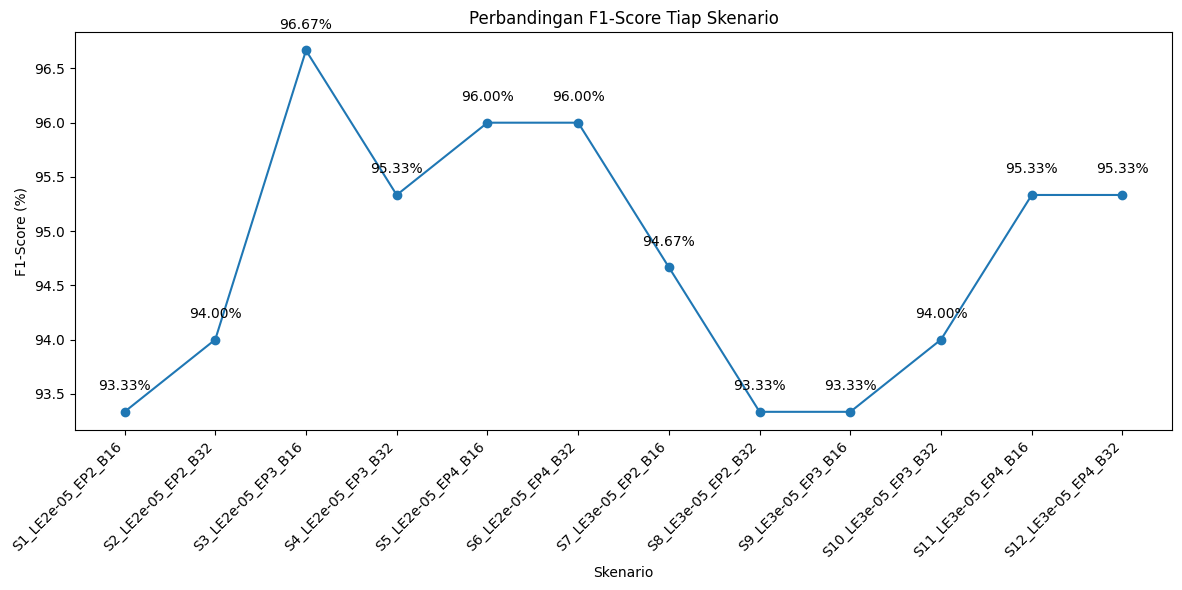

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))  # perbesar ukuran

plt.plot(skenario, f1_score, marker='o')

# Tambahkan label persen
for i in range(len(f1_score)):
    plt.text(i, f1_score.iloc[i] + 0.2, f"{f1_score.iloc[i]:.2f}%", ha='center')

plt.title("Perbandingan F1-Score Tiap Skenario")
plt.xlabel("Skenario")
plt.ylabel("F1-Score (%)")

# Putar label biar ga numpuk
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
save_dir = "./model_indoBERT_sentimen"

trainer.save_model(save_dir)          # simpan model
tokenizer.save_pretrained(save_dir)   # simpan tokenizer

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model_indoBERT_sentimen/tokenizer_config.json',
 './model_indoBERT_sentimen/tokenizer.json')

In [ ]:
import shutil
shutil.make_archive("model_indoBERT_sentimen", "zip", save_dir)

'/content/model_indoBERT_sentimen.zip'

In [ ]:
#Mengambil model terbaik
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df.head()


,Skenario,LE,Epoch,Batch,Train Loss,Eval Loss,Accuracy,Precision,Recall,F1,Model_Path
2,S3_LE2e-05_EP3_B16,0.00002,3,16,0.097883,0.246546,0.966667,0.961538,0.974026,0.967742,./best_model/S3_LE2e-05_EP3_B16
4,S5_LE2e-05_EP4_B16,0.00002,4,16,0.023722,0.336191,0.960000,0.949367,0.974026,0.961538,./best_model/S5_LE2e-05_EP4_B16
5,S6_LE2e-05_EP4_B32,0.00002,4,32,0.031933,0.369295,0.960000,0.949367,0.974026,0.961538,./best_model/S6_LE2e-05_EP4_B32
3,S4_LE2e-05_EP3_B32,0.00002,3,32,0.030796,0.216455,0.953333,0.972973,0.935065,0.953642,./best_model/S4_LE2e-05_EP3_B32
10,S11_LE3e-05_EP4_B16,0.00003,4,16,0.004018,0.480546,0.953333,0.926829,0.987013,0.955975,./best_model/S11_LE3e-05_EP4_B16


In [ ]:
best_experiment = results_df.iloc[0]

print("Model terbaik :", best_experiment["Skenario"])
print("LR            :", best_experiment["LE"])
print("Epoch         :", best_experiment["Epoch"])
print("Batch size    :", best_experiment["Batch"])

Model terbaik : S3_LE2e-05_EP3_B16
LR            : 2e-05
Epoch         : 3
Batch size    : 16


In [ ]:
# 1. Load model terbaik (fresh)
best_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# 2. TrainingArguments
best_args = TrainingArguments(
    output_dir="./model_final_indobert",

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=50,           #menampilkan setiap 50 step
    logging_first_step=True,    #step pertama langsung muncul

    learning_rate=best_experiment["LE"],
    num_train_epochs=int(best_experiment["Epoch"]),
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=int(best_experiment["Batch"] // 8),

    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    fp16=True,
    report_to="none"
)

# 3. Trainer
best_trainer = Trainer(
    model=best_model,
    args=best_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

# 4. Train
best_trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.750379,0.179731,0.926667,0.929032,0.923077,0.935065
2,0.450187,0.164640,0.940000,0.942675,0.925000,0.961039
3,0.171845,0.198740,0.926667,0.929936,0.912500,0.948052


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=228, training_loss=0.4153852901960674, metrics={'train_runtime': 127.3962, 'train_samples_per_second': 28.329, 'train_steps_per_second': 1.79, 'total_flos': 237391949698560.0, 'train_loss': 0.4153852901960674, 'epoch': 3.0})

In [ ]:
best_trainer.save_model("./model_final_indobert3")
tokenizer.save_pretrained("./model_final_indobert3")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model_final_indobert3/tokenizer_config.json',
 './model_final_indobert3/tokenizer.json')

In [ ]:
# Menyimpan model final
shutil.make_archive("model_final_indobert3", "zip", save_dir)

'/content/model_final_indobert3.zip'

In [ ]:
#Menyimpan result
shutil.make_archive("/content/results3", "zip", save_dir)

'/content/results3.zip'

In [ ]:
#Menyimpan best_model
shutil.make_archive("/content/best_model3", "zip", save_dir)

'/content/best_model3.zip'

# **EVALUASI**

In [ ]:
# Mengecek apakah model overrfiting
# Evaluasi data training
train_result = trainer.evaluate(train_dataset)

# Evaluasi data validation
val_result = trainer.evaluate(val_dataset)

print("Train:", train_result)
print("Validation:", val_result)

Train: {'eval_loss': 0.01839245855808258, 'eval_accuracy': 0.9966749792186201, 'eval_f1': 0.9967532467532467, 'eval_precision': 0.9967532467532467, 'eval_recall': 0.9967532467532467, 'eval_runtime': 3.0743, 'eval_samples_per_second': 391.306, 'eval_steps_per_second': 49.116, 'epoch': 4.0}
Validation: {'eval_loss': 0.5736533403396606, 'eval_accuracy': 0.9533333333333334, 'eval_f1': 0.9559748427672956, 'eval_precision': 0.926829268292683, 'eval_recall': 0.987012987012987, 'eval_runtime': 0.3745, 'eval_samples_per_second': 400.527, 'eval_steps_per_second': 50.733, 'epoch': 4.0}


In [ ]:
# Mengubah ke presentase
train_result = trainer.evaluate(train_dataset)
val_result = trainer.evaluate(val_dataset)

print("=== TRAIN ===")
print(f"Akurasi   : {train_result['eval_accuracy']*100:.2f}%")
print(f"Precision : {train_result['eval_precision']*100:.2f}%")
print(f"Recall    : {train_result['eval_recall']*100:.2f}%")
print(f"F1-Score  : {train_result['eval_f1']*100:.2f}%")

print("\n=== VALIDATION ===")
print(f"Akurasi   : {val_result['eval_accuracy']*100:.2f}%")
print(f"Precision : {val_result['eval_precision']*100:.2f}%")
print(f"Recall    : {val_result['eval_recall']*100:.2f}%")
print(f"F1-Score  : {val_result['eval_f1']*100:.2f}%")

=== TRAIN ===
Akurasi   : 99.67%
Precision : 99.68%
Recall    : 99.68%
F1-Score  : 99.68%

=== VALIDATION ===
Akurasi   : 95.33%
Precision : 92.68%
Recall    : 98.70%
F1-Score  : 95.60%


In [ ]:
selisih = train_result['eval_accuracy'] - val_result['eval_accuracy']
print(f"Selisih akurasi: {selisih*100:.2f}%")

Selisih akurasi: 4.33%


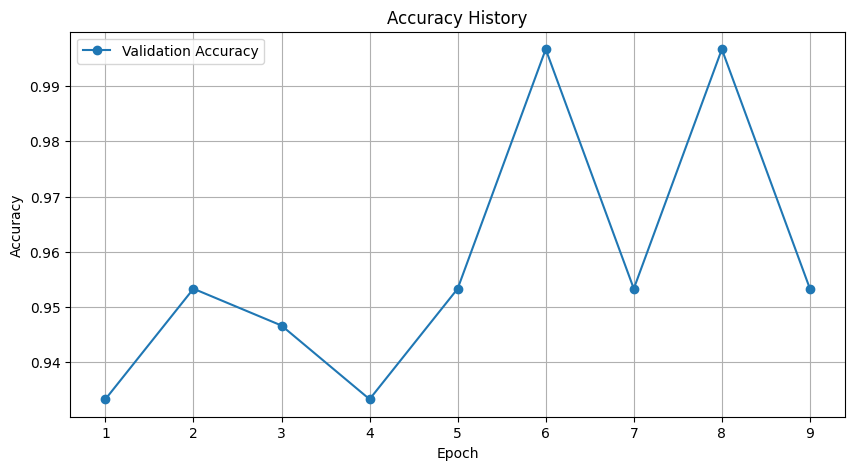

In [ ]:
plt.figure(figsize=(10,5))

# Training Accuracy (kalau ada)
if 'accuracy' in history.columns:
    train_acc = history[history['accuracy'].notna()]['accuracy']
    plt.plot(range(1, len(train_acc)+1), train_acc, label='Training Accuracy', marker='o')

# Validation Accuracy
plt.plot(range(1, len(val_accuracy)+1), val_accuracy, label='Validation Accuracy', marker='o')

plt.title("Accuracy History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Tes ke data tes
# Test ke data Test
test_result = best_trainer.evaluate(test_dataset)
print(test_result)

{'eval_loss': 0.3092310428619385, 'eval_accuracy': 0.9006622516556292, 'eval_f1': 0.9056603773584906, 'eval_precision': 0.8780487804878049, 'eval_recall': 0.935064935064935, 'eval_runtime': 0.4928, 'eval_samples_per_second': 306.44, 'eval_steps_per_second': 38.559, 'epoch': 3.0}


In [ ]:
# Evaluasi akhir data testing
import numpy as np
from sklearn.metrics import classification_report

pred = best_trainer.predict(test_dataset)
y_pred = np.argmax(pred.predictions, axis=1)

print(classification_report(test_labels, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.86      0.90        74
           1       0.88      0.94      0.91        77

    accuracy                           0.90       151
   macro avg       0.90      0.90      0.90       151
weighted avg       0.90      0.90      0.90       151



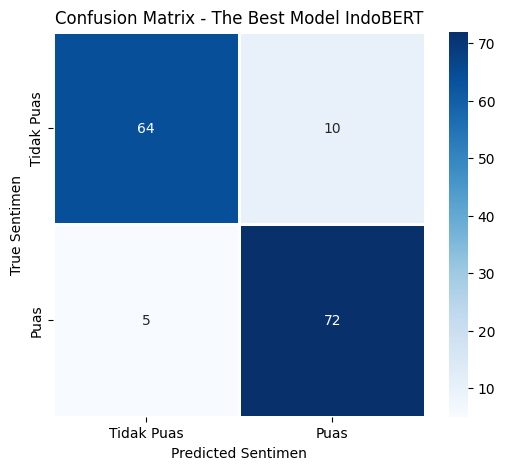

In [ ]:
import seaborn as sns

# Menghitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

labels = ["Tidak Puas", "Puas"]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor='white'
)

plt.title("Confusion Matrix - The Best Model IndoBERT")
plt.xlabel("Predicted Sentimen")
plt.ylabel("True Sentimen")

plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(test_labels, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()

df_report.index = ['Negatif', 'Positif', 'Accuracy', 'Macro Avg', 'Weighted Avg']

# Ubah ke persen
df_report[['precision','recall','f1-score']] = df_report[['precision','recall','f1-score']].applymap(lambda x: f"{x:.2f}%")

print(df_report)

             precision recall f1-score     support
Negatif          0.93%  0.86%    0.90%   74.000000
Positif          0.88%  0.94%    0.91%   77.000000
Accuracy         0.90%  0.90%    0.90%    0.900662
Macro Avg        0.90%  0.90%    0.90%  151.000000
Weighted Avg     0.90%  0.90%    0.90%  151.000000


/tmp/ipykernel_601/199770265.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_report[['precision','recall','f1-score']] = df_report[['precision','recall','f1-score']].applymap(lambda x: f"{x:.2f}%")


In [ ]:
# Merubah str menjadi float
# Ambil hanya baris kelas (0 dan 1)
df_plot = df_report.iloc[:2][['precision','recall','f1-score']]

# Ubah ke numeric (hapus % kalau ada)
df_plot = df_plot.replace('%','', regex=True).astype(float)

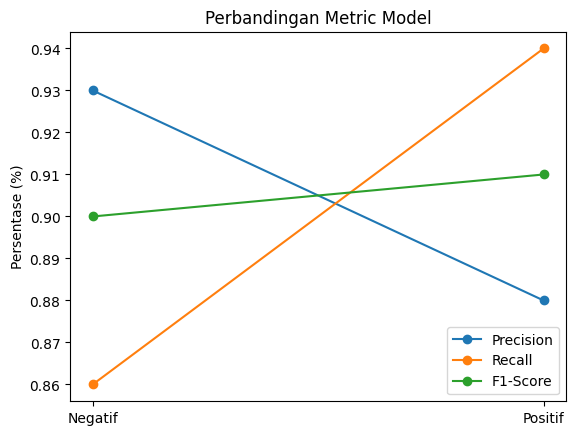

In [ ]:
plt.plot(df_plot.index, df_plot['precision'], marker='o', label='Precision')
plt.plot(df_plot.index, df_plot['recall'], marker='o', label='Recall')
plt.plot(df_plot.index, df_plot['f1-score'], marker='o', label='F1-Score')

plt.title("Perbandingan Metric Model")
plt.ylabel("Persentase (%)")
plt.legend()
plt.show()

In [ ]:
# Nyoba pake data manual
teks_baru = ["pelayanannya baik tapi ada beberapa hal yang perlu di tingkatkan"]

inputs = tokenizer(
    teks_baru,
    padding=True,
    truncation=True,
    return_tensors="pt"
).to(best_trainer.model.device)

outputs = best_trainer.model(**inputs)
prediksi = outputs.logits.argmax(dim=1).item()

label_map = {0: "Tidak Puas", 1: "Puas"}
print(label_map[prediksi])

Puas


# **DEPLOYMENT**

In [ ]:
import zipfile

with zipfile.ZipFile('/content/model_final_indobert3.zip', 'r') as zip_ref:
    zip_ref.extractall('final_indobert')

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/content/final_indobert"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
text = "AC Rusak"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

outputs = model(**inputs)
pred = torch.argmax(outputs.logits).item()

print(pred)

0


Data Asli

In [ ]:
import pandas as pd

df = pd.read_csv("/content/ulasan_cleaning.csv")

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits).item()
    return pred

df["prediksi_sentimen"] = df["ulasan"].apply(predict_sentiment)

df.head()

,fakultas,angkatan,ulasan,ulasan_clean,prediksi_sentimen
0,Fakultas Keguruan dan Ilmu Pendidikan,2023,0,0,0
1,Fakultas Ekonomi dan Bisnis,2024,"""Bapak/Ibu sekalian, terima kasih banyak atas ...",bapak ibu sekalian terima kasih banyak atas se...,1
2,Fakultas Keguruan dan Ilmu Pendidikan,2024,1. Dimohon untuk fasilitas yang sering rusak a...,1 dimohon untuk fasilitas yang sering rusak ag...,0
3,Fakultas Keguruan dan Ilmu Pendidikan,2024,1. infocus banyak yang tidak nyala\n2. Ac yang...,1 infocus banyak yang tidak nyala 2 ac yang ti...,0
4,Fakultas Hukum,2023,1. KRS setiap mata kuliah harusnya tertera di ...,1 krs setiap mata kuliah harusnya tertera di s...,0


/tmp/ipykernel_601/1462072376.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{v} data\n({percentages[i]:.2f}%)",


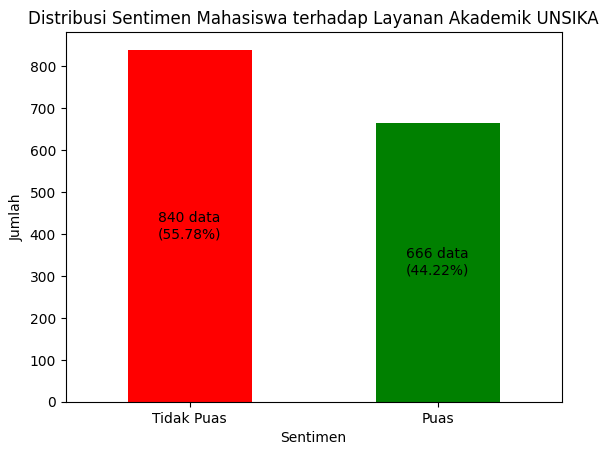

In [ ]:
import matplotlib.pyplot as plt

# Mapping label
label_map = {0: "Tidak Puas", 1: "Puas"}

# Hitung jumlah + ubah label
counts = df["prediksi_sentimen"].map(label_map).value_counts()

# Hitung persentase
percentages = counts / counts.sum() * 100

# Plot
ax = counts.plot(kind="bar", color=['red', 'green'])

# Tambahkan jumlah + persen di dalam bar
for i, v in enumerate(counts):
    ax.text(
        i, v/2,
        f"{v} data\n({percentages[i]:.2f}%)",
        ha='center',
        va='center',
        color='black',
        fontsize=10
    )

plt.title("Distribusi Sentimen Mahasiswa terhadap Layanan Akademik UNSIKA")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

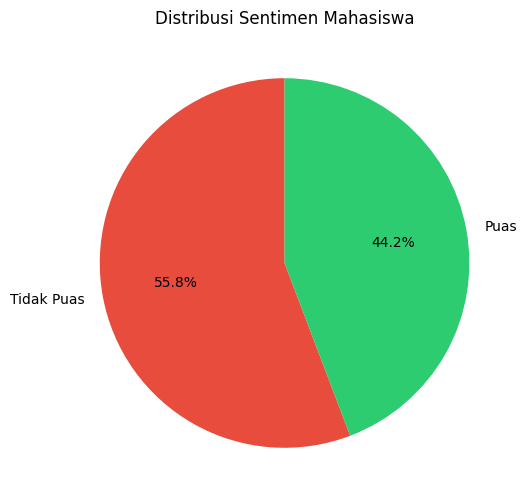

In [ ]:
#Pie Chart
# Mapping label
label_map = {0: "Tidak Puas", 1: "Puas"}

# Hitung jumlah + ubah label
counts = df["prediksi_sentimen"].map(label_map).value_counts()

# Pastikan urutan
counts = counts[["Tidak Puas", "Puas"]]

# Warna
colors = ['#e74c3c', '#2ecc71']  # merah & hijau

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',  # tampilkan persen
    colors=colors,
    startangle=90
)

plt.title("Distribusi Sentimen Mahasiswa")
plt.show()

In [ ]:
#Distribusi sentimen fakultas
sentimen_fakultas = pd.crosstab(df['fakultas'], df['prediksi_sentimen'])

print(sentimen_fakultas)

prediksi_sentimen                        0    1
fakultas                                       
Fakultas Agama Islam                    58   64
Fakultas Ekonomi dan Bisnis            132  120
Fakultas Hukum                          40   44
Fakultas Ilmu Kesehatan                 25   40
Fakultas Ilmu Komputer                 113   71
Fakultas Ilmu Sosial dan Ilmu Politik   84   64
Fakultas Keguruan dan Ilmu Pendidikan  213  142
Fakultas Pertanian                      40   39
Fakultas Teknik                        135   82


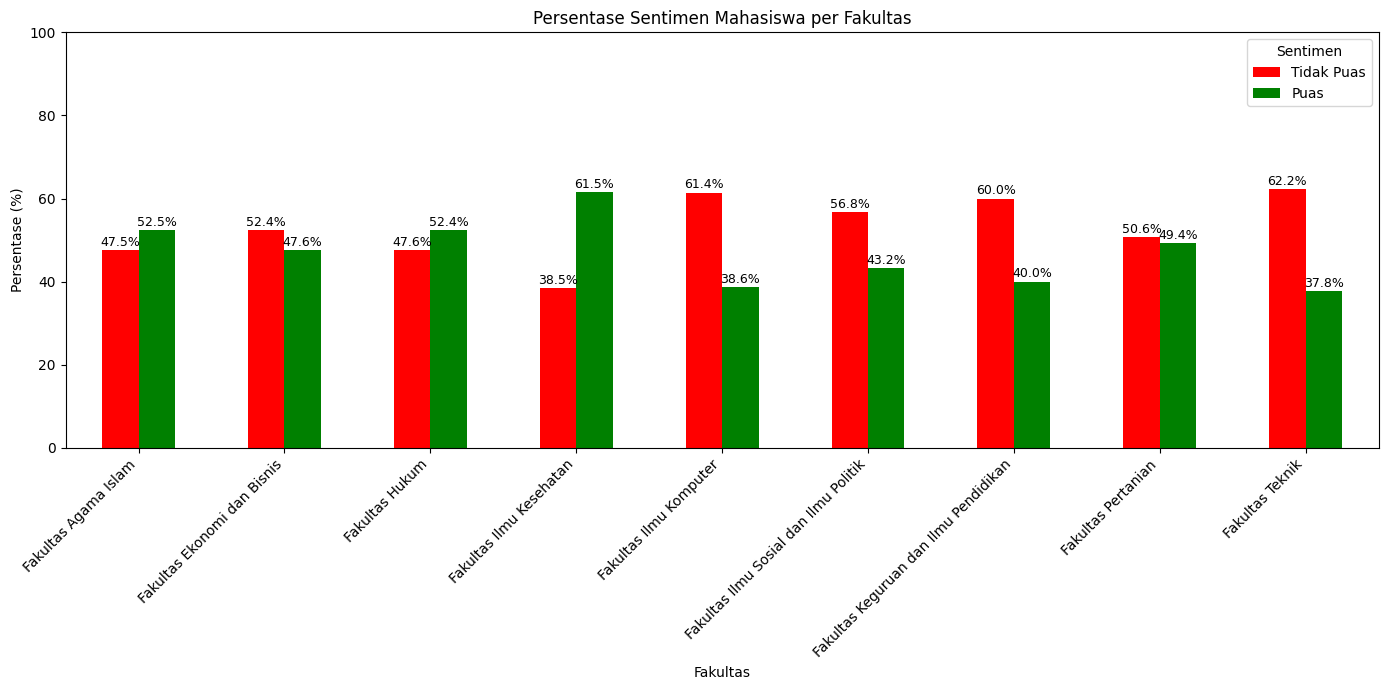

In [ ]:
#Visualisasi per fakultas
# Mapping label
label_map = {0: "Tidak Puas", 1: "Puas"}

# Crosstab
sentimen_fakultas = pd.crosstab(
    df['fakultas'],
    df['prediksi_sentimen'].map(label_map)
)

# Pastikan urutan kolom
sentimen_fakultas = sentimen_fakultas[["Tidak Puas", "Puas"]]

# Hitung persentase per fakultas
sentimen_persen = sentimen_fakultas.div(sentimen_fakultas.sum(axis=1), axis=0) * 100

# Plot grouped bar dengan warna
ax = sentimen_persen.plot(
    kind='bar',
    figsize=(14,7),
    color=['red', 'green']
)

# Tambahkan label persen
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 1,
                f"{height:.1f}%",
                ha='center',
                fontsize=9
            )

plt.title("Persentase Sentimen Mahasiswa per Fakultas")
plt.xlabel("Fakultas")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Sentimen")
plt.ylim(0, 100)  # biar skala jelas
plt.tight_layout()
plt.show()

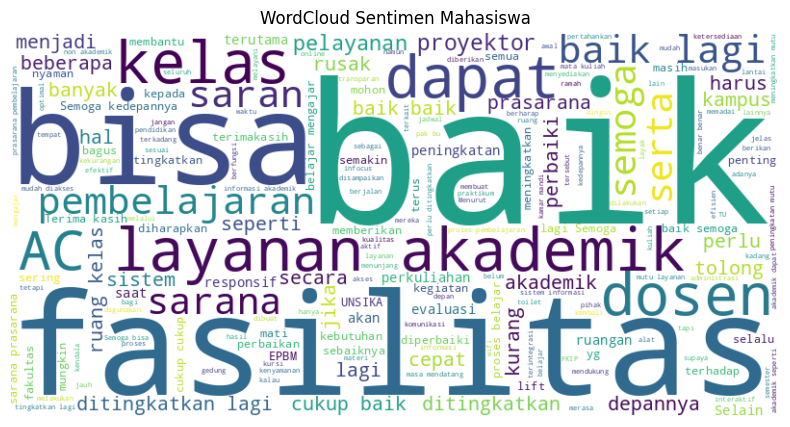

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Stopwords manual (SUDAH DIPERBAIKI)
stopwords_indonesia = {
    "saya","kami","kita","nya","juga","agar","lebih","sudah","sangat",
    "karena","oleh","sehingga","ada","ya","jadi","saja","mahasiswa","yang",
    "dan", "di", "ke", "dari", "untuk", "dengan", "pada", "dalam",
    "ini", "itu","tidak","atau"
}

# Gabungkan text (ganti 'ulasan' sesuai kolom kamu)
text_wordcloud = " ".join(df['ulasan'].dropna().astype(str))

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_indonesia
).generate(text_wordcloud)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Sentimen Mahasiswa")
plt.show()

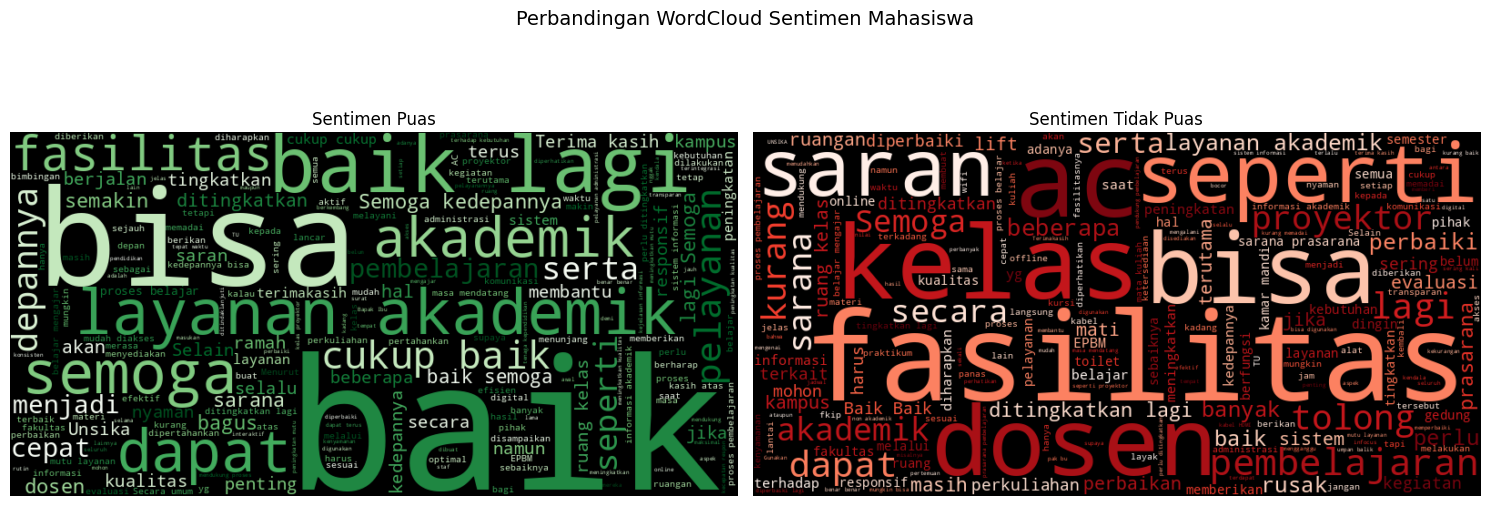

In [ ]:
# World Cloud per sentimen
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Stopwords manual
stopwords_indonesia = {
    "saya","kami","kita","nya","juga","agar","lebih","sudah","sangat",
    "karena","oleh","sehingga","ada","ya","jadi","saja","mahasiswa","yang",
    "dan", "di", "ke", "dari", "untuk", "dengan", "pada", "dalam",
    "ini", "itu","tidak","atau"
}

# Ambil text per sentimen (ganti 'ulasan' jika beda)
text_puas = " ".join(
    df[df['prediksi_sentimen'] == 1]['ulasan'].dropna().astype(str)
)

text_tidak_puas = " ".join(
    df[df['prediksi_sentimen'] == 0]['ulasan'].dropna().astype(str)
)

# WordCloud Puas (Hijau)
wc_puas = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Greens',
    stopwords=stopwords_indonesia
).generate(text_puas)

# WordCloud Tidak Puas (Merah)
wc_tidak = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Reds',
    stopwords=stopwords_indonesia
).generate(text_tidak_puas)

# Plot berdampingan
plt.figure(figsize=(15,6))

# Puas
plt.subplot(1, 2, 1)
plt.imshow(wc_puas, interpolation='bilinear')
plt.axis('off')
plt.title("Sentimen Puas")

# Tidak Puas
plt.subplot(1, 2, 2)
plt.imshow(wc_tidak, interpolation='bilinear')
plt.axis('off')
plt.title("Sentimen Tidak Puas")

# Judul utama
plt.suptitle("Perbandingan WordCloud Sentimen Mahasiswa", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("Hasil Analisis sentimen(Data asli)3.csv", index=False)